In [7]:
#!/usr/bin/env python3
# plot_hrdpsn.py
# Standalone: xarray + cartopy plot for ECCC-HRDPSN curvilinear grid

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# --------- CONFIG ---------
# Path to your file (change if needed)
NCFILE = "/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/models/ECCC-HRDPSN/48h_rmse.ECCC-HRDPSN_202404.nc"

ds = xr.open_dataset(NCFILE)


In [11]:
ds.nav_lat[10,10].values

array(0., dtype=float32)

Data shapes (y, x): (945, 906)
Lon range (wrapped): 0.0 → 0.0
Lat range: 0.0 → 0.0
Color limits: 0.6330326843261719 3.704091439247131
Auto extent used: [-1.0, 1.0, -1.0, 1.0]


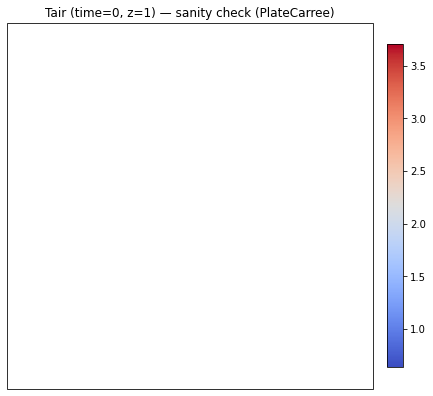

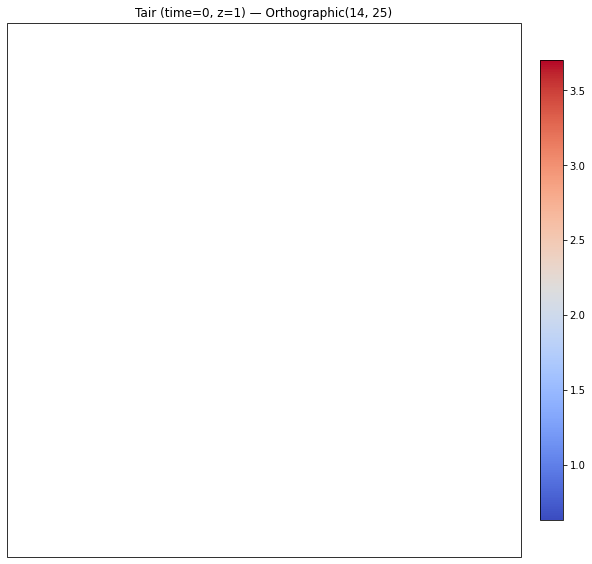

In [2]:
#!/usr/bin/env python3
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ---------------- CONFIG ----------------


# Which slice to show
VAR_NAME = "Tair"        # (time_counter, z, y, x)
LAT_NAME = "nav_lat"     # (y, x)
LON_NAME = "nav_lon"     # (y, x)
TIME_IDX = 0
Z_IDX    = 1
CMAP     = "coolwarm"
VMIN, VMAX = None, None  # set to None first; script will auto-guess
ORTHO_CENTRE = (14, 25)  # (lon, lat)
# ---------------------------------------

def wrap_lon_180(lon):
    lon = np.array(lon, copy=True)
    # If any longitude > 180, assume 0..360 and wrap
    if np.nanmax(lon) > 180:
        lon = np.where(lon > 180, lon - 360, lon)
    return lon

def nanify_fill(a):
    a = np.array(a, copy=True)
    # Common CF attributes; xarray usually handles, but be safe
    a = np.where(np.isfinite(a), a, np.nan)
    # also nuke giant sentinel fills
    a = np.where(np.abs(a) > 1e20, np.nan, a)
    return a

def data_bbox(lon, lat):
    # robust nan-safe min/max
    return (np.nanmin(lon), np.nanmax(lon),
            np.nanmin(lat), np.nanmax(lat))

def main():
    ds = xr.open_dataset(NCFILE, decode_times=False)  # time not needed for plotting

    # --- Pull variables ---
    if VAR_NAME not in ds:
        raise KeyError(f"{VAR_NAME} not in dataset. Available: {list(ds.data_vars)}")
    for nm in (LAT_NAME, LON_NAME):
        if nm not in ds:
            raise KeyError(f"{nm} not in dataset. Available: {list(ds.data_vars) + list(ds.coords)}")

    var_da = ds[VAR_NAME].isel(time_counter=TIME_IDX, z=Z_IDX)  # -> (y, x)
    lat = ds[LAT_NAME].values
    lon = ds[LON_NAME].values

    # shapes must match
    if var_da.shape != lat.shape or var_da.shape != lon.shape:
        raise ValueError(f"Shape mismatch: {VAR_NAME}{var_da.shape}, {LAT_NAME}{lat.shape}, {LON_NAME}{lon.shape}")

    # cleanup
    var = nanify_fill(var_da.values)
    lat = nanify_fill(lat)
    lon = wrap_lon_180(nanify_fill(lon))

    # auto color limits if not provided
    finite = np.isfinite(var)
    if not finite.any():
        raise RuntimeError("All values are NaN after masking. Check slicing (time/z), variable name, or fill values.")
    vmin = VMIN if VMIN is not None else np.nanpercentile(var, 2)
    vmax = VMAX if VMAX is not None else np.nanpercentile(var, 98)
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmin, vmax = np.nanmin(var), np.nanmax(var)

    # compute data bounds and add a small buffer for the extent
    lon_min, lon_max, lat_min, lat_max = data_bbox(lon, lat)
    dlon = max(1.0, 0.05 * (lon_max - lon_min))
    dlat = max(1.0, 0.05 * (lat_max - lat_min))
    extent = [lon_min - dlon, lon_max + dlon, lat_min - dlat, lat_max + dlat]

    # -------- Figure 1: PlateCarree sanity plot with auto extent --------
    fig1 = plt.figure(figsize=(8, 7))
    ax1 = plt.axes(projection=ccrs.PlateCarree())
    ax1.set_title(f"{VAR_NAME} (time={TIME_IDX}, z={Z_IDX}) — sanity check (PlateCarree)")
    ax1.coastlines(resolution="50m", linewidth=0.6)
    ax1.add_feature(cfeature.BORDERS, linewidth=0.3)
    mesh1 = ax1.pcolormesh(lon, lat, var, transform=ccrs.PlateCarree(),
                           cmap=CMAP, vmin=vmin, vmax=vmax, shading="auto")
    ax1.set_extent(extent, crs=ccrs.PlateCarree())
    plt.colorbar(mesh1, ax=ax1, orientation="vertical", shrink=0.85, pad=0.03)

    # -------- Figure 2: Orthographic centred on your view --------
    proj = ccrs.Orthographic(*ORTHO_CENTRE)
    fig2 = plt.figure(figsize=(9, 8))
    ax2 = plt.axes(projection=proj)
    ax2.set_title(f"{VAR_NAME} (time={TIME_IDX}, z={Z_IDX}) — Orthographic{ORTHO_CENTRE}")
    ax2.coastlines(resolution="50m", linewidth=0.6)
    ax2.add_feature(cfeature.BORDERS, linewidth=0.3)
    # Use same transform (data is lon/lat)
    mesh2 = ax2.pcolormesh(lon, lat, var, transform=ccrs.PlateCarree(),
                           cmap=CMAP, vmin=vmin, vmax=vmax, shading="auto")
    # Clip to data bounds; if you want your fixed box, replace with your extent
    ax2.set_extent(extent, crs=ccrs.PlateCarree())
    plt.colorbar(mesh2, ax=ax2, orientation="vertical", shrink=0.85, pad=0.03)

    # -------- Diagnostics in console --------
    print("Data shapes (y, x):", var.shape)
    print("Lon range (wrapped):", float(np.nanmin(lon)), "→", float(np.nanmax(lon)))
    print("Lat range:", float(np.nanmin(lat)), "→", float(np.nanmax(lat)))
    print("Color limits:", vmin, vmax)
    print("Auto extent used:", extent)

    plt.tight_layout()
    plt.show()
    ds.close()

if __name__ == "__main__":
    main()


In [4]:
lat

NameError: name 'lat' is not defined

In [6]:
#!/usr/bin/env python3
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# ------------- CONFIG -------------
NCFILE   = "48h_rmse.ECCC-HRDPSN_202404.nc"
NCFILE = "/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/models/ECCC-HRDPSN/48h_rmse.ECCC-HRDPSN_202404.nc"

VAR_NAME = "Tair"         # (time_counter, z, y, x)
TIME_IDX = 0
Z_IDX    = 1
CMAP     = "coolwarm"
ORTHO_CENTER = (14, 25)   # your viewing projection
# ----------------------------------

def build_crs_from_grid_mapping(gm_attrs):
    """
    Build a Cartopy CRS from CF grid_mapping attributes.
    Handles Lambert Conformal (most common for HRDPS).
    Extend if your file uses another projection.
    """
    name = gm_attrs.get("grid_mapping_name", "").lower()

    if "lambert_conformal" in name:
        # Accept both lambert_conformal and lambert_conformal_conic
        cl = gm_attrs.get("longitude_of_central_meridian",
                          gm_attrs.get("longitude_of_projection_origin", 0.0))
        lat0 = gm_attrs.get("latitude_of_projection_origin", 0.0)

        # standard parallels can be 1 or 2 values
        sp1 = gm_attrs.get("standard_parallel")
        if isinstance(sp1, (list, tuple, np.ndarray)):
            sps = tuple(sp1)
        elif sp1 is not None:
            sps = (float(sp1), )
        else:
            # sometimes given as two separate keys
            sp_a = gm_attrs.get("standard_parallel_1")
            sp_b = gm_attrs.get("standard_parallel_2")
            sps = tuple([v for v in (sp_a, sp_b) if v is not None]) or (lat0, )

        fe = gm_attrs.get("false_easting", 0.0)
        fn = gm_attrs.get("false_northing", 0.0)

        return ccrs.LambertConformal(
            central_longitude=float(cl),
            central_latitude=float(lat0),
            standard_parallels=tuple(map(float, sps)),
            false_easting=float(fe),
            false_northing=float(fn),
        )

    raise NotImplementedError(
        f"Unsupported or missing grid_mapping_name='{name}'. "
        "Add a handler for your projection."
    )

def main():
    # Don't need time decoding; keeps things simple
    ds = xr.open_dataset(NCFILE, decode_times=False)

    # --- pick the field (y, x) ---
    da = ds[VAR_NAME].isel(time_counter=TIME_IDX, z=Z_IDX)

    # --- coordinates: try lon/lat, else projected x/y + grid_mapping ---
    lon_name = next((n for n in ("nav_lon", "lon", "longitude") if n in ds), None)
    lat_name = next((n for n in ("nav_lat", "lat", "latitude") if n in ds), None)

    use_xy = False
    if lon_name and lat_name:
        lon = ds[lon_name].values
        lat = ds[lat_name].values
        if np.nanmax(np.abs(lon)) == 0 and np.nanmax(np.abs(lat)) == 0:
            # present but useless → fall back to projected coords
            use_xy = True
    else:
        use_xy = True

    if use_xy:
        # Expect 1D x and y coordinates
        x_name = next((n for n in ("x", "X") if n in ds), None)
        y_name = next((n for n in ("y", "Y") if n in ds), None)
        if x_name is None or y_name is None:
            raise KeyError("Projected grid detected but no 1D 'x'/'y' coordinates found.")

        x = ds[x_name].values
        y = ds[y_name].values
        # Make 2D arrays for pcolormesh
        X, Y = np.meshgrid(x, y)

        # Build native CRS from grid_mapping on the data variable
        gm_name = da.attrs.get("grid_mapping")
        if gm_name is None or gm_name not in ds:
            raise KeyError("No CF grid_mapping found on the variable.")
        native_crs = build_crs_from_grid_mapping(ds[gm_name].attrs)

        data = da.where(np.isfinite(da)).values
        vmin = np.nanpercentile(data, 2)
        vmax = np.nanpercentile(data, 98)

        # --- Plot ---
        fig = plt.figure(figsize=(10, 8))
        ax = plt.axes(projection=ccrs.Orthographic(*ORTHO_CENTER))
        ax.coastlines(resolution="50m", linewidth=0.7)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)

        # NOTE: transform=native_crs because X,Y are in the native projection
        mesh = ax.pcolormesh(X, Y, data, transform=native_crs,
                             cmap=CMAP, vmin=vmin, vmax=vmax, shading="auto")

        # If you want to zoom roughly, compute native extent and apply in PlateCarree
        # by transforming a few edge points to lon/lat; here we just show all:
        plt.colorbar(mesh, ax=ax, shrink=0.82, pad=0.03, orientation="vertical")
        ax.set_title(f"{VAR_NAME} (time={TIME_IDX}, z={Z_IDX}) — native projected grid")
        plt.tight_layout()
        plt.show()

    else:
        # We *do* have lon/lat and they are non-zero: standard curvilinear path
        lon = ds[lon_name].values
        lat = ds[lat_name].values
        if np.nanmax(lon) > 180:
            lon = np.where(lon > 180, lon - 360, lon)
        data = da.where(np.isfinite(da)).values
        vmin = np.nanpercentile(data, 2)
        vmax = np.nanpercentile(data, 98)

        fig = plt.figure(figsize=(10, 8))
        ax = plt.axes(projection=ccrs.Orthographic(*ORTHO_CENTER))
        ax.coastlines(resolution="50m", linewidth=0.7)
        ax.add_feature(cfeature.BORDERS, linewidth=0.3)
        mesh = ax.pcolormesh(lon, lat, data, transform=ccrs.PlateCarree(),
                             cmap=CMAP, vmin=vmin, vmax=vmax, shading="auto")
        plt.colorbar(mesh, ax=ax, shrink=0.82, pad=0.03, orientation="vertical")
        ax.set_title(f"{VAR_NAME} (time={TIME_IDX}, z={Z_IDX}) — curvilinear lon/lat")
        plt.tight_layout()
        plt.show()

    ds.close()

if __name__ == "__main__":
    main()


KeyError: "Projected grid detected but no 1D 'x'/'y' coordinates found."